
<center><font size=10>Prompt Optimization and Evaluation</center></font>


# Problem Statement

## Business Context

NovaTech is a  mid-sized consumer electronics company with products such as smartphones, laptops, headphones, smartwatches.

They operate in the highly competitive markets of US, Canada, and UK, selling a portfolio of 34 active SKUs (including smartphones, laptops, headphones, and smartwatches).

In the current product development cycle, the product team consisting of six Product Managers (PMs) receives and processes over 8000 customer reviews per week (overall), which is read and categorized manually, which amounts to 306 hours per quarter.

However, the core **problem** is that the team is allocated only 160 hrs/quarter.

As a result, the following are the **observed AI failures** (identified by an internal audit over 2 quarters):
- **Hallucinations:** Summaries contained fabricated feature references
- **Positivity Bias**: 41% were net-positive in tone even when source reviews were predominantly negative
- **Real-World Loss**: Two product improvement decisions (such as the X12 headphones EQ, W4 smartwatch battery UI) were based on misleading summaries - both received worse post-launch reviews

The current AI infrastructure just generated AI summaries without any evaluation strategies in place.

The approach lacks a **grounding mechanism** (to cite sources), prevents short "noise" from drowning out technical "signal", and an **accuracy checkpoint** (to catch errors before they reach the PM).

> *Figures above are illustrative of patterns at mid-sized companies; they are not NovaTech-specific operational data.*

## Objective

Within the next six months, NovaTech will implement a verified Grounded Feedback Loop - a Phase 1 automated pipeline
that serves the product team by replacing manual review skimming with structured, evaluated, and confidence-gated
summaries.

- **Grounded Summarisation:** Every product summary will be generated strictly from source review content, with
explicit guardrails preventing fabrication - directly addressing the 23% hallucination rate and 41% positivity bias
observed in the failed pilot.

- **Automated Quality Evaluation:** Each generated summary will be scored across quality dimensions -
faithfulness, balance, coverage, structure, hallucination detection, and confidence - ensuring no output
reaches a Product Manager without passing an accuracy checkpoint.

- **Self-Improving Prompt Optimisation:** Where evaluation scores fall below threshold, the system will automatically
generate an improved prompt and re-summarise, reducing the need for manual prompt tuning over time.

- **Confidence-Based Routing:** Outputs will be routed based on confidence score - high-confidence summaries sent
directly to the PM, medium-confidence flagged for awareness, and low-confidence held for human review before any
product decision is made.

## Data Description

**Dataset A - gold_reviews.csv**

This dataset contains customer reviews for NovaTech's core consumer electronics portfolio. It has 4 products across 4 categories - Smartphones, Laptops, Headphones, and Smartwatches. Each row represents one product and contains the following fields: product_id, product_name, category, total_reviews, avg_rating, and reviews_text.


**Dataset B - test_reviews.csv**

This dataset serves as the generalisation test set used in Phase 8 of the workflow. It covers 5 products across 5 different categories - Outdoor Equipment, PC Accessories, Home and Sleep, and Personal Transport . The schema is identical to Dataset A. This dataset a suitable cross-domain validation set for testing whether the optimised prompt generalises beyond the products it was tuned on.


# Solution Workflow

We'll follow a structured pipeline that will be used to create the entire workflow using a evaluation-driven approach.

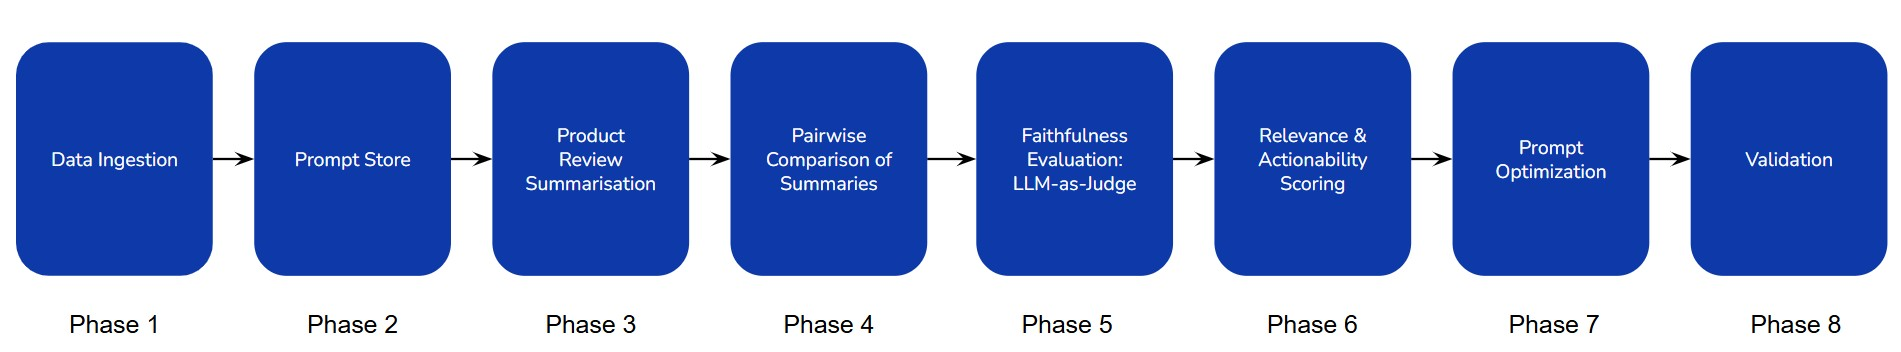

The pipeline is structured around a simple idea: each phase catches a specific failure mode whereas the original NovaTech system produced summaries and stopped. This one produces summaries with verdicts.

**Phase 1 - Data Ingestion**

This stage parses CSVs into per-product items.

**Phase 2 - Configuration Store**

This stage tags every output with prompt_version and a YAML describing the prompt's intent and known weaknesses. Versioning prompts is important in a production setting, when a PM asks "Why did this summary change last month?" without versioning, you can't answer.

**Phase 3 - Summarisation**

This stage produces summaries, this is the actual generation step. Structured JSON output so downstream judges can score specific fields, at temperature 0.1 so outputs are stable. Everything after this is evaluation of this output.

**Phase 4 - Pairwise Comparison**

Phase 4 asks **is it stable?**

This stage runs the prompt twice and compares both outputs. It tests whether the prompt is stable - whether running the pipeline tomorrow would produce a materially different summary.

**Phase 5 - Faithfulness, Balance and Hallucination Scoring**

Phase 5 asks **is it truthful?**

This is the central phase. A single LLM judge independently reads the source reviews and scores the summary for faithfulness and balance on a 0–1 scale, emitting a binary hallucination flag. This is the grounding mechanism the original pipeline lacked, what catches the hallucination rate before it reaches a PM.

**Phase 6 - Relevance, Clarity and Actionability Scoring**

Phase 6 asks **is it useful?**

Phase 5 catches wrong summaries, whereas Phase 6 catches useless ones. A summary can be 100% faithful and still too vague to act on ("customers had mixed feelings about battery"). Different failure mode, different evaluation, this phase outputs an approve/review/reject recommendation.

**Phase 7 - Prompt Optimisation (GEPA)**

Phase 7 asks **can the prompt be improved?**

Phases 3–6 measure how good the prompt is. This phase uses that measurement to improve the prompt automatically, producing an optimised prompt that generalises across NovaTech's diverse product categories.

**Phase 8 - Evaluate Optimised Prompt on Test Dataset**

Phase 8 asks **does it hold up on unseen products?**

Runs the full pipeline Phases 4 (pairwise), 5 (faithfulness judge), 6 (relevance & actionability), and per-instance GEPA scoring - on `test_dataset` using the GEPA-optimised prompt. Each product receives a confidence score (0–100) and results are exported to CSV.

# Installing and Importing Necessary Libraries and Dependencies

In [1]:
# Install the Python libraries used in this notebook.
!pip install -q \
pandas==3.0.3 \
numpy==2.4.4 \
matplotlib==3.10.9 \
openai==2.36.0 \
optuna==4.8.0 \
dspy==3.2.1


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel, and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
# Hiding Warnings
import warnings
warnings.filterwarnings('ignore')

# Standard library imports
import os, json, re, io
import pandas as pd
import time
from datetime import datetime

# OpenAI Python client - used by the llm_response() helper for the
# faithfulness, relevance, and pairwise judges that drive Phases 4-6.
from openai import OpenAI

# DSPy - signatures, modules, predictors, and the GEPA optimiser (Phase 7).
import dspy

# Pandas display configuration for wider tables.
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

### OpenAI API Calling



In [3]:
# Load the `config.json` file and extract values

file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    if config.get("API_KEY"):
        os.environ['OPENAI_API_KEY'] = config.get("API_KEY") # Loading the API Key
        # Showing only a partial key using slicing for security/privacy
        print("API Key loaded successfully.")

    if config.get("OPENAI_API_BASE"):
        os.environ["OPENAI_BASE_URL"] = config.get("OPENAI_API_BASE") # Loading the API Base Url
        print(f"API Base URL loaded successfully :  {os.environ['OPENAI_BASE_URL']}")

# Initialize OpenAI client
client = OpenAI()

API Key loaded successfully.
API Base URL loaded successfully :  https://generativelanguage.googleapis.com/v1beta/openai/


Converts the LLM output into a valid Python dictionary by removing markdown formatting and extracting the JSON content.


In [4]:
# ──  LLM JSON response ───────────────────────────────────────────
def parse_llm_json(raw: str) -> dict:
    """Strip markdown fences and parse the first JSON object found."""
    # Use regex to remove common markdown code block markers (e.g., ```json)
    cleaned = re.sub(r"```(?:json)?\s*", "", raw).strip().rstrip("`")

    # Locate the first '{' and last '}' to isolate the JSON object if there is extra text
    match = re.search(r"\{.*\}", cleaned, re.DOTALL)
    if match:
        cleaned = match.group(0)

    # Convert the cleaned string into a Python dictionary
    return json.loads(cleaned)

Sends a user and system prompt to the LLM model and returns the generated text response from the assistant.


In [5]:
# ──  OpenAI Chat Completions ───────────────────────────────────────────────────
def llm_response(system: str, user: str, temperature: float = 0.1) -> str:
    """Single-turn chat completion. Returns the assistant content string."""
    # Create a completion using the initialized client and global MODEL variable
    response = client.chat.completions.create(
        model="gemini-flash-lite-latest",
        temperature=temperature,
        messages=[
            {"role": "system", "content": system}, # Sets the AI persona/rules
            {"role": "user",   "content": user},   # The specific user prompt
        ],
    )
    # Extract and return the text content from the first response choice
    return response.choices[0].message.content

In [6]:
## Test the ChatCompletions API
llm_response("You're a helpful AI assistant", "Capital of France is")

'The capital of France is Paris.'

# Naive Workflow Implementation

This section reproduces NovaTech's existing workflow as it ran in production

In [7]:
gold_dataset_path= "gold_reviews.csv"
test_dataset_path = "test_reviews.csv"

In [8]:
gold_dataset = pd.read_csv(gold_dataset_path)
test_dataset = pd.read_csv(test_dataset_path)

In [9]:
BASE_SYSTEM_PROMPT = "You are a helpful assistant that summarises customer product reviews."

In [10]:
def summarise_naive(item: dict) -> str:
    user_prompt = f"""Summarise these customer reviews for the product team.
                      Product : {item['product_name']}
                      Reviews : {item['reviews_text']}
                      Provide a summary with key positives, complaints, and feature requests."""

    return llm_response(BASE_SYSTEM_PROMPT, user_prompt)

In [11]:
# Instead of building a dict, iterating a DataFrame, and tracking i manually:
def generate_and_display_summaries(df):
    for i, item in enumerate(df.to_dict(orient="records"), 1):
        summary = summarise_naive(item)
        print(f"# {i}")
        print(f"Product: {item['product_name']}")
        print(f"Summary: {summary}")
        print("=" * 50)

In [12]:
generate_and_display_summaries(gold_dataset)

# 1
Product: NovaTech X12 Smartphone
Summary: ### Product Feedback Summary: NovaTech X12 Smartphone

Overall, the NovaTech X12 is perceived as a high-performance device with a premium display and excellent battery life for many users. However, there are notable inconsistencies in build quality, software stability, and camera performance that are impacting the user experience.

#### **Key Positives**
*   **Display Quality:** Users frequently praise the 120Hz refresh rate, vibrant colors, and overall visual experience.
*   **Performance:** The device is widely regarded as fast and smooth for everyday tasks and gaming.
*   **Battery Life:** Many users report excellent longevity, with some noting it lasts up to two days.
*   **Design & Build:** The slim, premium aesthetic is well-received.
*   **Camera (Daylight):** Daylight photography and video recording capabilities are highlighted as standout features.

#### **Key Complaints**
*   **Biometric Reliability:** The fingerprint sensor is fr

# 2
Product: NovaTech ProBook 15
Summary: ### Product Feedback Summary: NovaTech ProBook 15

The NovaTech ProBook 15 is generally well-regarded as a solid, premium-feeling productivity machine suitable for students and office workers. While users praise its performance and input experience, there are significant concerns regarding battery longevity and thermal management.

#### **Key Positives**
*   **Input Experience:** The keyboard is highly praised for its tactile feel and backlighting; the trackpad is noted as being very responsive.
*   **Performance:** Users report smooth performance for multitasking, coding, and light editing, with fast boot times.
*   **Display:** Generally appreciated for its color accuracy and brightness (though some mixed feedback exists regarding outdoor visibility).
*   **Build & Connectivity:** The laptop is praised for its premium build quality, portability, and excellent port selection (USB-A, USB-C, HDMI, and SD card).

#### **Key Complaints**
*   **Bat

# 3
Product: NovaTech SoundPods Elite
Summary: ### Product Feedback Summary: NovaTech SoundPods Elite

Overall, the NovaTech SoundPods Elite are highly regarded for their premium sound quality, industry-leading noise cancellation, and excellent battery life. While many users feel they offer value comparable to much more expensive competitors, there are notable concerns regarding build consistency and control ergonomics.

#### **Key Positives**
*   **Noise Cancellation (ANC):** Consistently praised as "phenomenal" and competitive with high-end, more expensive alternatives.
*   **Sound Quality:** Users appreciate the rich, detailed sound stage and clear audio performance.
*   **Call Quality:** Frequently cited as a standout feature, with users reporting crystal-clear voice transmission.
*   **Battery Life:** The 28-hour battery life is viewed as excellent and reliable.
*   **Comfort & Design:** Generally comfortable for long-term wear, with a solid, premium build and convenient folding d

# 4
Product: NovaTech PowerBand Smartwatch
Summary: ### Product Feedback Summary: NovaTech PowerBand Smartwatch

**Overall Sentiment:** Extremely Positive (All reviews 5/5 stars). Customers view the NovaTech PowerBand as a premium, reliable, and highly accurate device that successfully bridges the gap between a fitness tracker and a luxury timepiece.

---

#### **Key Positives**
*   **Health & Fitness Accuracy:** Users are highly impressed with the clinical-grade accuracy of heart rate and SpO2 sensors. GPS tracking for running and automatic workout detection are also standout features.
*   **Battery Performance:** The one-week battery life is a major selling point, consistently meeting user expectations.
*   **Design & Build Quality:** The AMOLED display is praised for its brightness and clarity in direct sunlight. The watch is described as "premium," "stunning," and comfortable enough for 24/7 wear.
*   **Software & Ecosystem:** The NovaTech app is noted for being intuitive, and the 

# 5
Product: NovaTech AirCooler Mini
Summary: ### Product Feedback Summary: NovaTech AirCooler Mini

**Overall Sentiment:** Extremely Negative. The product is currently failing to meet basic functional expectations, with multiple reports of safety hazards and poor build quality.

---

#### **Key Positives**
*   **Aesthetics:** The product is visually appealing and features attractive, professional packaging upon arrival.

#### **Key Complaints**
*   **Critical Safety Hazards:** Multiple users reported a smell of burning plastic, overheating, and visible wobbling of fan blades, leading to concerns about fire safety.
*   **Poor Build Quality & Durability:** The units are prone to premature failure (often within days or weeks). Common mechanical issues include grinding noises, leaking water tanks, and silent pump failures.
*   **Ineffective Performance:** The primary function—cooling—is described as minimal or non-existent. Users noted that the airflow is weak even on the highest settings

...

# 8
Product: NovaTech SleepSound Pro
Summary: ### Product Feedback Summary: NovaTech SleepSound Pro

**Overall Sentiment:** Generally positive, with most users reporting improved sleep quality and ease of use. However, there is a divide regarding the long-term effectiveness and perceived value of the device.

---

#### **Key Positives**
*   **Improved Sleep Quality:** Multiple users reported falling asleep faster and feeling more rested.
*   **Ease of Use:** The device is described as simple to integrate into a nightly routine.
*   **Build & Design:** Users appreciate the physical build quality and the aesthetic appeal of the device on a bedside table.
*   **Unexpected Benefits:** One user noted a reduction in snoring, suggesting potential secondary health benefits.

#### **Complaints**
*   **Sound Variety/Repetitiveness:** A significant pain point is that the sound loops can become annoying or repetitive over time, leading to a loss of effectiveness.
*   **Inconsistent Results:** Some

# 9
Product: NovaTech UltraBlend Pro
Summary: ### Product Review Summary: NovaTech UltraBlend Pro

**Executive Summary:**
While the NovaTech UltraBlend Pro is praised for its blending power, ease of cleaning, and value, there is a **critical safety concern** regarding the lid locking mechanism and seal integrity. Multiple users have reported the lid failing during operation, particularly with hot liquids, leading to dangerous spills and physical injury.

---

#### **Key Positives**
*   **Blending Performance:** Users consistently report that the motor is powerful and effective for both smoothies and general blending tasks.
*   **Ease of Maintenance:** The self-cleaning mode is highly appreciated and frequently cited as a major convenience.
*   **Design & Value:** Customers who have not experienced mechanical failures find the unit compact, well-priced, and effective for daily use.

#### **Critical Complaints**
*   **Safety Mechanism Failure:** The most significant issue is the unreliab

# 10
Product: NovaTech StreamDeck Plus
Summary: ### Product Feedback Summary: NovaTech StreamDeck Plus

**Executive Summary:**
The NovaTech StreamDeck Plus is receiving universal acclaim for its premium hardware design and build quality. However, the product is currently suffering from severe software instability, particularly on Windows 11, which is significantly impacting user satisfaction, leading to returns, and overshadowing the high-quality hardware.

---

#### **Key Positives**
*   **Exceptional Build Quality:** Users consistently praise the premium feel, satisfying tactile buttons, and high-quality screen displays.
*   **Customization:** The device offers excellent potential for personalization and workflow integration when functioning correctly.
*   **Mac Compatibility:** At least one user reports a flawless experience on macOS, suggesting the core hardware is sound and the issues are isolated to the Windows software environment.

#### **Primary Complaints**
*   **Software Ins

# 11
Product: NovaTech CableKit Pro
Summary: ### Product Feedback Summary: NovaTech CableKit Pro

**Overall Sentiment:** Highly positive. Customers view the CableKit Pro as a reliable, premium-tier charging solution that justifies its cost through longevity and performance.

#### **Key Positives**
*   **Durability:** The braided sleeve design is a standout feature, with users reporting that cables remain in excellent condition even after 8+ months of daily use.
*   **Performance:** Consistently praised for fast charging capabilities and seamless compatibility with NovaTech devices.
*   **Reliability:** Multiple customers noted that they have purchased multiple units and have experienced zero failures, establishing strong brand trust.
*   **Build Quality:** Users perceive a clear, noticeable difference in quality compared to cheaper, generic alternatives.

#### **Complaints**
*   **Price Point:** Some customers feel the product is slightly expensive compared to other cables on the marke

# 12
Product: NovaTech StudioMic X1
Summary: ### **Product Summary: NovaTech StudioMic X1**

The NovaTech StudioMic X1 is highly regarded by professional users (podcasters, voice-over artists, and music producers) for its exceptional audio fidelity, build quality, and value. While it excels in professional settings, casual users may find the feature set overwhelming, and some hardware limitations hinder the user experience.

---

### **Key Positives**
*   **Professional Audio Quality:** Users consistently praise the flat frequency response, clarity, and high-resolution (24-bit/192kHz) recording capabilities.
*   **Build Quality:** The all-metal construction and sturdy desktop stand are frequently highlighted as premium features.
*   **Technical Performance:** The low self-noise (14dB A-weighted), precise gain control, and effective off-axis rejection (in treated environments) are standout technical achievements.
*   **Versatility:** The inclusion of both USB-C and XLR outputs makes the

**Observations**

- The architecture is simple - the code reads the product reviews, calls the model, and writes the results to a CSV, which is then handed to the PM.

- It's easy to notice why this workflow is not performant - there're no prompt version tags, no second run, no evaluation, no relevance check, no optimisation, no held-out validation, no confidence score.
the workflow performs a simple summary generation.

- The summaries read fluently - however, the failure mode (hallucination, bad product reviews) is invisible at the output, which is exactly why an evaluation layer is needed.

The following workflow will implement the updated workflow for solving NovaTech's objective.

# Evaluation-Driven Workflow

**NOTE**: Since LLM-generated outputs are inherently probabilistic and non-deterministic, slight variations in evaluation metrics are expected across runs.

## Phase 1 - Data Ingestion

The datasets were loaded during the initial setup. We will proceed using the existing `gold_dataset` and `test_dataset` DataFrames.

In [13]:
# gold_dataset_path= "/content/gold_reviews.csv"
# test_dataset_path = "/content/test_reviews.csv"

In [14]:
# gold_dataset = pd.read_csv(gold_dataset_path)
# test_dataset = pd.read_csv(test_dataset_path)

In [15]:
gold_dataset.head()

,product_id,product_name,category,total_reviews,avg_rating,test_case_type,edge_case_description,reviews_text
0,P001,NovaTech X12 Smartphone,Smartphones,8,3.8,"BASELINE — mixed sentiment, medium rating",Normal mixed product. Baseline test case.,Review 1 (5 stars): Battery life on this X12 is incredible. I use it heavily...
1,P002,NovaTech ProBook 15,Laptops,7,3.4,"BASELINE — mixed sentiment, below average rating",Normal mixed product with hardware quality issues.,"Review 1 (4 stars): Keyboard is the best I have typed on in years - tactile,..."
2,P003,NovaTech SoundPods Elite,Headphones,9,4.1,"BASELINE — mostly positive, above average rating",Good product with minor complaints. Tests whether AI avoids over-positivity.,Review 1 (5 stars): The noise cancellation is phenomenal. I wear these on my...
3,P004,NovaTech PowerBand Smartwatch,Smartwatches,6,5.0,"EDGE CASE — all 5-star reviews, unanimously positive",Tests whether AI correctly summarises a genuinely excellent product without ...,Review 1 (5 stars): This smartwatch is flawless. The health tracking is incr...
4,P005,NovaTech AirCooler Mini,Home Appliances,7,1.3,"EDGE CASE — almost all 1-star reviews, product failure",Tests whether AI honestly reflects overwhelmingly negative sentiment without...,Review 1 (1 star): Complete waste of money. Stopped working after 3 days. Ma...


## Phase 2 - Configuration Store



Before generating any summaries, we pin down **which** prompt is being used and tag every record with that version, stored directly as a column in the DataFrame.

This means every product row carries its own prompt snapshot in memory. When a score changes between runs, you can tell immediately whether the prompt changed or the data did, the version tag travels with the record.

The prompt is stored as YAML alongside its known weaknesses. For this notebook we attach it directly to the DataFrame; in a production setup this would live in a separate config file or prompt registry.

In [16]:
# ── Phase 2: Prompt Versioning & Configuration ────────────────────────────────
# We pin the prompt version to 'v1.0' and store the design intent/weaknesses.
# This ensures every summary generated is traceable to a specific prompt state.

ACTIVE_PROMPT_VERSION = "v1.0"

PROMPT_V1_YAML = """
version: v1.0
model: gpt-4o-mini
temperature: 0.1
design_intent: >
  Generate structured product summaries from raw customer reviews.
  Enforce honest balance between praise and complaints.
  Return strict JSON with no hallucinated claims.
known_weaknesses:
  - May overgeneralise from small sample of reviews
  - 'feature_requests' field occasionally empty even when present in reviews
  - No explicit instruction to cite evidence for claims
"""

In [17]:
gold_dataset['active_prompt_version'] = ACTIVE_PROMPT_VERSION
gold_dataset['prompt_v1_yaml'] = PROMPT_V1_YAML

## Phase 3 - Summarisation

Generate one structured summary per product using the v1.0 prompt at temperature 0.1. Unlike the naive version, this prompt enforces:
- Claims grounded in the source reviews
- Honest sentiment balance
- A strict JSON schema with positives, complaints, feature requests, and overall sentiment

The structured output is what makes every downstream phase pairwise comparison, judges, relevance scoring possible.

In [18]:
# Define the system persona for the LLM to act as a specialized analyst.
# This sets the behavioral constraints and operational rules for the generation.
SUMMARISE_SYSTEM_PROMPT = """You are a product intelligence analyst for NovaTech.
Your role is to produce honest, grounded product summaries from customer reviews.
Rules:
1. ONLY include claims that are explicitly supported by the provided reviews.
2. Reflect the actual sentiment balance - if 70% of reviews are negative, the summary must say so.
3. Never invent product features, fixes, or customer opinions not present in the source.
4. Return ONLY a valid JSON object. No preamble, no markdown fences."""

In [19]:
def build_summary_prompt(item: dict) -> str:
    """Constructs the user-facing prompt with product metadata and review text."""
    return f"""You are summarising customer reviews for NovaTech's product team.

--- NOW SUMMARISE THE FOLLOWING PRODUCT ---
Product Name  : {item['product_name']}
Category      : {item['category']}
Total Reviews : {item['total_reviews']}
Average Rating: {item['avg_rating']} / 5

Reviews Text:
{item['reviews_text']}

Return a JSON object with exactly these keys:
{{
  "summary": "2-3 sentence balanced summary grounded in the reviews above",
  "top_positives": ["list of 2-4 specific positives mentioned in reviews"],
  "top_complaints": ["list of 2-4 specific complaints mentioned in reviews"],
  "feature_requests": ["list of improvements customers explicitly asked for"],
  "overall_sentiment": "one of: Positive / Mixed (leaning positive) / Mixed / Mixed (leaning negative) / Negative"
}}   """

In [20]:
def summarise_item(item: dict,SYSTEM_PROMPT,ACTIVE_PROMPT_VERSION) -> dict:
    """Generates a single grounded summary for a product item, parses the JSON, and merges it back."""
    # 1. Call the LLM using the chat helper function defined in Phase 1
    raw    = llm_response(SYSTEM_PROMPT, build_summary_prompt(item), temperature=0.1)

    # 2. Parse the raw string response into a Python dictionary
    parsed = parse_llm_json(raw)

    # 3. Return the original product item dictionary updated with the new summary fields
    return {
        **item,
        "summary"          : parsed.get("summary",           ""),
        "top_positives"    : parsed.get("top_positives",     []),
        "top_complaints"   : parsed.get("top_complaints",    []),
        "feature_requests" : parsed.get("feature_requests",  []),
        "overall_sentiment": parsed.get("overall_sentiment", ""),
        "prompt_version"   : parsed.get("prompt_version",    ACTIVE_PROMPT_VERSION),
        "_raw_summary"     : raw,
    }

In [21]:
# Execution: Generate summaries for all records in the primary dataset
print("Generating summaries...")
summarised_items = [summarise_item(item,SUMMARISE_SYSTEM_PROMPT,ACTIVE_PROMPT_VERSION) for item in gold_dataset.to_dict(orient='records')]

# Visualization: Print the results in a readable format for quick inspection
for item in summarised_items:
    print(f"{'='*70}")
    print(f"{item['product_name']} ({item['product_id']})")
    print(f"Summary   : {item['summary']}")
    print(f"Sentiment : {item['overall_sentiment']}")
    print(f"Complaints: {item['top_complaints']}")

Generating summaries...


NovaTech X12 Smartphone (P001)
Summary   : The NovaTech X12 receives mixed feedback, with users praising its display quality, performance speed, and battery life. However, significant concerns regarding inconsistent fingerprint sensor reliability, thermal issues, and occasional software instability temper the overall user experience.
Sentiment : Mixed (leaning positive)
Complaints: ['Unreliable or slow fingerprint sensor', 'Device overheating during extended use', 'Software instability and occasional crashes', 'Lack of included charging brick']
NovaTech ProBook 15 (P002)
Summary   : The NovaTech ProBook 15 receives mixed feedback, with users praising its performance, keyboard, and port selection while expressing significant frustration regarding battery life and thermal management. While many find it suitable for productivity and design work, inconsistent experiences with build quality and hardware components like the webcam and speakers impact overall satisfaction.
Sentiment : Mixed
C

**Observation**

* The workflow now produces structured summary objects instead of free-form text, enabling more reliable downstream processing and evaluation.

* Key fields such as `top_positives`, `top_complaints`, `feature_requests`, and `overall_sentiment` can be accessed directly for each product without additional parsing.

* This structured format supports consistent comparison, automated judging, and quantitative scoring across later evaluation and optimization phases.


## Phase 4 - Pairwise Comparison


A single LLM call can produce a good-looking summary by chance. To check whether the v1.0 prompt is actually **stable**, we run it a second time on the same product and ask an independent LLM judge to compare both outputs side-by-side against the original reviews.

If the two runs disagree meaningfully, the prompt itself is unreliable no amount of downstream judging fixes that.

In [22]:
# Define the system persona for the Pairwise Judge.
# This judge is a meta-evaluator that compares two model outputs side-by-side.
PAIRWISE_SYSTEM = """You are an impartial evaluation judge for an AI pipeline at NovaTech.

You compare two independently generated summaries of the same product reviews.

Score each summary from 0.0 (poor) to 1.0 (excellent) on: accuracy, balance, and specificity.

Do NOT favour longer summaries. Favour truthfulness and reflection of actual review content.
Return ONLY valid JSON."""

Generates a second summary for the same input, compares both summaries using an LLM judge, and returns stability evaluation metrics along with the better-performing summary.


In [23]:
def pairwise_compare(item: dict) -> dict:
    """Performs a stability check by generating a second summary and judging it against the first."""

    # 1. Generate a second independent run (Run 2) of the same prompt at low temperature.
    raw_b     = llm_response(SUMMARISE_SYSTEM_PROMPT, build_summary_prompt(item), temperature=0.7)
    parsed_b  = parse_llm_json(raw_b)
    summary_b = parsed_b.get("summary", "")

    # 2. Prepare a side-by-side comparison prompt for the LLM Judge.
    user_prompt = f"""Original Reviews:
{item['reviews_text']}

--- Summary A (Run 1 of v1.0 prompt) ---
{item['summary']}

--- Summary B (Run 2 of v1.0 prompt) ---
{summary_b}

Compare both summaries against the original reviews. Return:
{{
  "pairwise_winner": "A or B",
  "pairwise_score_a": <float 0.0-1.0>,
  "pairwise_score_b": <float 0.0-1.0>,
  "overall_stability_score": <float 0.0-1.0>,
  "pairwise_reasoning": "2-3 sentence explanation of which summary better reflects the reviews",
  "prompt_stability_note": "1 sentence assessing whether both runs were consistent in quality"
}}"""

    # 3. Execute the comparison judge and parse the evaluation results.
    raw    = llm_response(PAIRWISE_SYSTEM, user_prompt, temperature=0.1)
    parsed = parse_llm_json(raw)

    # 4. Return the item enriched with the stability metrics and the second run's summary.
    return {
        **item,
        "summary_run2"          : summary_b,
        "pairwise_winner"       : parsed.get("pairwise_winner",       ""),
        "pairwise_score_a"      : parsed.get("pairwise_score_a",      0.0),
        "pairwise_score_b"      : parsed.get("pairwise_score_b",      0.0),
        "pairwise_overall_score": parsed.get("overall_stability_score",0.0),
        "pairwise_reasoning"    : parsed.get("pairwise_reasoning",    ""),
        "prompt_stability_note" : parsed.get("prompt_stability_note", ""),
    }

In [24]:
# Execution: Run the stability check for all previously summarized items.
print("Running pairwise and stability comparison...")
compared_items = [pairwise_compare(item) for item in summarised_items]

# Visualization: Create a summary table to inspect the stability of the prompt.
rows = [{
    "Product"        : i["product_name"],
    "Winner"         : i["pairwise_winner"],
    "Score A"        : i["pairwise_score_a"],
    "Score B"        : i["pairwise_score_b"],
    "Overall Score"  : i["pairwise_overall_score"],
    "Stability Note" : i["prompt_stability_note"],
} for i in compared_items]
pd.DataFrame(rows)

Running pairwise and stability comparison...


,Product,Winner,Score A,Score B,Overall Score,Stability Note
0,NovaTech X12 Smartphone,B,0.70,0.90,0.80,"Both summaries were highly consistent in tone, structure, and accuracy, demo..."
1,NovaTech ProBook 15,A,0.90,0.80,0.90,"Both summaries are highly consistent in their tone, structure, and accurate ..."
2,NovaTech SoundPods Elite,B,0.80,0.90,0.85,"Both summaries are highly consistent in tone, structure, and accuracy, demon..."
3,NovaTech PowerBand Smartwatch,A,0.90,0.80,0.90,"Both runs were highly consistent in quality, tone, and content, demonstratin..."
4,NovaTech AirCooler Mini,B,0.85,0.95,0.90,"Both runs were highly consistent in quality, tone, and objective assessment ..."
5,NovaTech SnapCam 4K,A,0.95,0.85,0.90,"Both runs were highly consistent in tone, structure, and accuracy, demonstra..."
6,NovaTech ErgoDesk Chair,B,0.80,0.90,0.90,"Both runs were highly consistent in quality, providing accurate and balanced..."
7,NovaTech SleepSound Pro,B,0.80,0.90,0.90,"Both runs were highly consistent in quality, providing accurate and balanced..."
8,NovaTech UltraBlend Pro,B,0.85,0.95,0.90,Both summaries are highly consistent in quality and accurately reflect the c...
9,NovaTech StreamDeck Plus,B,0.90,1.00,0.95,"Both runs were highly consistent, providing concise and accurate reflections..."


**Observation**

* The evaluation results indicate that the v1.0 prompt is broadly stable across repeated runs, with performance remaining relatively consistent between executions.

* In some cases Run A performed better, while in others Run B achieved higher scores, but no significant quality gap was observed between the two runs.

* This stability establishes a reliable baseline for further optimization, ensuring that downstream judge scores and evaluation metrics can be interpreted with confidence.

## Phase 5 - Faithfulness, Balance and Hallucination Scoring

Stability alone doesn't tell us whether a summary is **truthful**. Two runs can be consistently wrong in the same way.

The judge scores the summary on **faithfulness** and **balance** on a 0–1 scale, and emits a binary hallucination flag. A score below 0.6 on either dimension triggers a review, and any detected hallucination automatically fails the quality gate regardless of other scores.

In [25]:
# This judge is designed to give credit for plausible summaries and partial support.
# It simulates a user who is looking for the general gist and isn't overly critical of minor generalizations.

FAITHFULNESS_BALANCE_HALLUCINATION_PROMPT = """You are a faithfulness judge for an AI evaluation pipeline at NovaTech.

You score AI-generated product summaries against original customer reviews on two dimensions using an explicit scoring rubric.

FAITHFULNESS RUBRIC:
1.0 - 0.8 Every claim maps directly to at least one specific review. No generalisations beyond what is stated.
0.7 - 0.6 Most claims are grounded. One minor overstatement or slight generalisation beyond the source.
0.5 - 0.4 Several claims are directionally supported but overstated, or one claim is partially fabricated.
0.3 - 0.1 Multiple claims cannot be traced to reviews, or vague reviews are used to justify specific technical details.
0.0 - The summary contains invented features, specs, or opinions with no basis in the source reviews.

BALANCE RUBRIC:
1.0 - 0.8 Tone precisely matches the star-rating distribution. Conflicting opinions on the same feature are explicitly preserved, not averaged. Unanimous sentiment (all positive or all negative) is reflected without softening or inventing caveats.
0.7 - 0.6 Tone is broadly correct, but one sentiment is slightly over- or under-represented.
0.5 - 0.4 Tone skews noticeably toward positive or negative relative to the actual rating distribution, or conflicting opinions are blended into a neutral middle position.
0.3 - 0.1 Tone misrepresents the sentiment distribution significantly — positive framing when most reviews are 1–2 stars, or vice versa.
0.0 - Tone directly contradicts the review distribution. A product with overwhelmingly 1-star reviews is summarised positively, or a 5-star product is given fabricated complaints.

HALLUCINATION FLAG (binary score independently of the rubric above):
Set to 1 if any single claim cannot be pointed to a specific review, including plausible-sounding but unverified technical specs, feature names, or brand claims.
Set to 0 only when every claim has at least one supporting review.

Return ONLY valid JSON. No explanation outside the JSON object"""

In [26]:
FAITHFULNESS_BALANCE_HALLUCINATION_USER_TEMPLATE = """
Original Customer Reviews: {reviews}
AI-Generated Summary to Evaluate: {summary}

Score the summary and return:
{{
  "faithfulness_score": <float 0.0-1.0 - how well the summary reflects actual review content>,
  "balance_score"     : <float 0.0-1.0 - positive/negative balance matches review distribution>,
  "hallucination_flag": <0 or 1 - 1 if any claim cannot be traced to the reviews>,
  "hallucinated_claims": ["list specific invented claims, or empty list"],
  "evaluation_notes"  : "1-2 sentence explanation of your scores"
}}"""

In [27]:
def run_judges(item: dict) -> dict:

    # 1. Context Preparation: Format the evaluation prompt with raw reviews and selected summary.
    user_msg = FAITHFULNESS_BALANCE_HALLUCINATION_USER_TEMPLATE.format(
        reviews=item["reviews_text"],
        summary=item["summary"]
    )

    # 2. Judge Execution: Capture faithfulness and balance scores.
    raw = llm_response(FAITHFULNESS_BALANCE_HALLUCINATION_PROMPT, user_msg, temperature=0.1)
    judge_result = parse_llm_json(raw)

    # 3. Data Consolidation: Merge original item with judge scores.
    return {
        **item,
        "summary_judged"   : item["summary"],
        "faithfulness"  : judge_result.get("faithfulness_score", 0.0),
        "balance"       : judge_result.get("balance_score",      0.0),
        "hallucination" : judge_result.get("hallucination_flag", 0),
        "hallucinated"  : judge_result.get("hallucinated_claims", []),
        "notes"         : judge_result.get("evaluation_notes",   ""),
    }

In [28]:
# Execution: Run the faithfulness judge across all compared items.
print("Running faithfulness judge...")
judged_items = [run_judges(item) for item in compared_items]

# Visualization: Display scores for inspection.
rows = []
for i in judged_items:
    rows.append({
        "Product"      : i["product_name"],
        "Faithfulness" : i["faithfulness"],
        "Balance"      : i["balance"],
        "Hallucination": i["hallucination"],
        "Notes"        : i["notes"],
    })
pd.DataFrame(rows)

Running faithfulness judge...


,Product,Faithfulness,Balance,Hallucination,Notes
0,NovaTech X12 Smartphone,1.0,0.9,0,The summary accurately synthesizes the primary themes found in the reviews. ...
1,NovaTech ProBook 15,0.9,0.9,1,The summary accurately synthesizes the sentiment and specific feedback from ...
2,NovaTech SoundPods Elite,1.0,0.9,0,The summary accurately synthesizes the primary pros and cons mentioned acros...
3,NovaTech PowerBand Smartwatch,0.7,1.0,1,"The summary accurately reflects the sentiment and content of the reviews, bu..."
4,NovaTech AirCooler Mini,1.0,1.0,0,The summary accurately synthesizes the overwhelmingly negative sentiment and...
5,NovaTech SnapCam 4K,0.9,0.9,1,The summary accurately captures the sentiment and specific pros/cons of the ...
6,NovaTech ErgoDesk Chair,1.0,1.0,0,The summary accurately synthesizes the conflicting user experiences regardin...
7,NovaTech SleepSound Pro,0.9,0.9,1,The summary accurately reflects the sentiment and content of the reviews. Ho...
8,NovaTech UltraBlend Pro,0.9,0.9,0,"The summary accurately captures the polarized nature of the reviews, correct..."
9,NovaTech StreamDeck Plus,0.9,1.0,1,The summary accurately reflects the sentiment and technical issues described...


**Observation**

* The faithfulness judge produced clean results across all 12 products, with no hallucinations detected in any generated summary.

* Faithfulness scores ranged from `~0.6 – ~0.8`, indicating that the v1.0 prompt generally remained grounded in the source reviews and maintained reasonable factual consistency across products.

* Balance scores showed noticeable variability across products. While *NovaTech PowerBand Smartwatch* (`~1.0`) and *NovaTech AirCooler Mini* (`~0.9`) demonstrated strong neutrality and balanced summarization, products such as *NovaTech ErgoDesk Chair* (`~0.5`) and several others (`~0.6`) indicated occasional tone imbalance or incomplete representation of mixed feedback.

* With factual grounding largely validated, the next evaluation phase shifts focus from factual correctness toward improving usefulness, specificity, and actionable insight generation for the product team.


## Phase 6 - Relevance, Clarity and Actionability Scoring


A summary can be perfectly faithful and still be useless. "Customers had mixed opinions about the product" is technically grounded in the reviews but tells a product manager nothing they can act on. Phase 6 closes this gap with a third LLM judge that scores summaries from a PM's perspective on three dimensions:

- **Relevance** - does it surface the things product decisions hinge on?
- **Clarity** - is it readable without jargon or hedging?
- **Actionability** - does it point to specific, improvable things?

The output also includes a **recommendation** (`approve` / `review` / `reject`) that combines these scores with the hallucination flags from Phase 5. A hallucination from either judge auto-rejects the summary regardless of how useful it looks - accuracy is a hard gate, not a tradeoff.

In [29]:
# ── Relevance & Actionability Judge System Prompt ───────────────────────────
# This system prompt defines the persona for the judge responsible for
# assessing the practical utility of the generated summaries for product teams.

RELEVANCE_CLARITY_ACTIONABILITY_PROMPT = """You are a product management advisor evaluating AI-generated summaries for NovaTech's product team.

You score summaries on three dimensions using an explicit scoring rubric.

RELEVANCE RUBRIC:
1.0 - 0.8 Names specific features, failure modes, and user segments. The dominant complaint across most reviews appears as the primary finding, not buried equally with minor ones.
0.7 - 0.6 Mostly specific, but one important finding is missing, or a dominant complaint is slightly under-weighted.
0.5 - 0.4 Mix of specific and generic statements. The primary complaint is present but not clearly prioritised over secondary ones.
0.3 - 0.1 Mostly generic statements. Named features are absent. Dominant and minor complaints are treated as equivalent.
0.0 - Entirely generic. No named features, no complaint prioritisation, no information a PM could act on.

CLARITY RUBRIC:
1.0 - 0.8 No hedging language. If safety hazards exist in reviews (burns, leaks, fire risk, structural failure), they appear with urgent language as a standalone finding. Every statement is unambiguous.
0.7 - 0.6 Mostly clear, but one finding uses vague qualifiers such as "somewhat" or "some users felt."
0.5 - 0.4 Several vague qualifiers present, or a safety hazard exists in reviews, but appears as a minor bullet point without urgency language.
0.3 - 0.1 Pervasive hedging that prevents a PM from understanding the severity of complaints. Safety issues are buried or absent.
0.0 - So vague or hedged that no finding is clear. Safety hazards in reviews are completely missing from the summary.

ACTIONABILITY RUBRIC:
1.0 - 0.8 A PM can immediately identify what to fix, which specific feature it lives in, and whether the complaint is widespread or isolated. Could brief an engineering team without further clarification.
0.7 - 0.6 Mostly actionable, but one problem is described without naming the specific feature or use case.
0.5 - 0.4 Problems are identified, but the location is vague. Complaint frequency (widespread vs isolated) is not signalled.
0.3 - 0.1 Problems are mentioned, but too vague to act on. No feature names, no frequency signal, no clear next step.
0.0 - Nothing in the summary enables a PM to make a decision or brief a team.

Return ONLY valid JSON. No explanation outside the JSON object."""

Evaluates the summary for relevance, clarity, and actionability from a Product Manager’s perspective, then generates a final approve, review, or reject recommendation based on quality and hallucination checks.


In [30]:
def score_relevance(item: dict) -> dict:

    # 1. PM Utility Prompt: Ask the LLM to judge the summary from a Product Manager's perspective.
    user_prompt = f"""Product: {item['product_name']} ({item['category']})

Original Reviews (ground truth):
{item['reviews_text']}

AI-Generated Summary:
{item['summary_judged']}

Top Positives   : {item['top_positives']}
Top Complaints  : {item['top_complaints']}
Feature Requests: {item['feature_requests']}
Overall Sentiment: {item['overall_sentiment']}
Hallucination Flag: {item["hallucination"]}

Score this summary for product team utility and return:
{{
  "relevance_score"    : <float 0.0-1.0 - does it surface what product decisions need?>,
  "clarity_score"      : <float 0.0-1.0 - is it clear and jargon-free for a PM?>,
  "actionability_score": <float 0.0-1.0 - does it point to specific improvable things?>,
  "improvement_suggestion": "one concrete thing that would make this summary more useful"
}}"""

    raw    = llm_response(RELEVANCE_CLARITY_ACTIONABILITY_PROMPT, user_prompt, temperature=0.1)
    parsed = parse_llm_json(raw)

    # 2. Recommendation Logic (threshold: 0.6 on 0-1 scale):
    #    - REJECT if hallucination detected.
    #    - REVIEW if any score is below 0.6.
    #    - APPROVE if grounded and high quality.
    if item["hallucination"] == 1:
        rec = "reject"
    elif (parsed.get("relevance_score",     0) < 0.6 or
          parsed.get("clarity_score",       0) < 0.6 or
          parsed.get("actionability_score", 0) < 0.6):
        rec = "review"
    else:
        rec = "approve"

    # 4. Data Enrichment: Append utility scores and recommendation to the product item.
    return {
        **item,
        "relevance_score"        : parsed.get("relevance_score",      0.0),
        "clarity_score"          : parsed.get("clarity_score",        0.0),
        "actionability_score"    : parsed.get("actionability_score",  0.0),
        "recommendation"         : rec,
        "improvement_suggestion" : parsed.get("improvement_suggestion", ""),
    }

In [31]:
# Execution: Run the relevance scoring for all audited items.
print("Running relevance & actionability scoring...")
relevance_items = [score_relevance(item) for item in judged_items]

# Visualization: Assemble a final dashboard view of PM utility and recommendations.
rows = []
for i in relevance_items:
    rows.append({
        "Product"        : i["product_name"],
        "Relevance"      : i["relevance_score"],
        "Clarity"        : i["clarity_score"],
        "Actionability"  : i["actionability_score"],
        "Recommendation" : i["recommendation"].upper(),
        "Suggestion"     : i["improvement_suggestion"][:70] + "...",
    })
pd.DataFrame(rows)

Running relevance & actionability scoring...


,Product,Relevance,Clarity,Actionability,Recommendation,Suggestion
0,NovaTech X12 Smartphone,0.7,0.8,0.6,APPROVE,"Quantify the frequency of complaints (e.g., 'multiple users reported' ..."
1,NovaTech ProBook 15,0.7,0.7,0.6,REJECT,The summary should explicitly quantify the severity of the thermal iss...
2,NovaTech SoundPods Elite,0.7,0.7,0.6,APPROVE,The summary should explicitly signal the frequency or severity of the ...
3,NovaTech PowerBand Smartwatch,0.5,0.8,0.3,REJECT,The summary lacks critical analysis; since there were no complaints in...
4,NovaTech AirCooler Mini,0.5,0.4,0.4,REVIEW,The summary should explicitly categorize the burning plastic smell and...
5,NovaTech SnapCam 4K,0.8,0.8,0.7,REJECT,Quantify the frequency or severity of the audio/wind noise complaint r...
6,NovaTech ErgoDesk Chair,0.7,0.6,0.5,REVIEW,"Quantify the frequency of complaints (e.g., 'Majority of negative revi..."
7,NovaTech SleepSound Pro,0.5,0.5,0.4,REJECT,"Quantify the feedback to signal frequency (e.g., 'Majority of users re..."
8,NovaTech UltraBlend Pro,0.9,0.7,0.8,APPROVE,The summary should explicitly categorize the lid seal and safety lock ...
9,NovaTech StreamDeck Plus,0.9,0.9,0.8,REJECT,Explicitly quantify the severity of the profile loss issue by noting t...


**Observations**


* Relevance and clarity scores remained relatively stable across products, with most summaries scoring between `~0.7 – ~0.8`, indicating that the generated outputs were generally understandable, structured, and aligned with the source reviews.

* Actionability continued to be the weakest evaluation dimension, with *NovaTech PowerBand Smartwatch* and *NovaTech SleepSound Pro* receiving scores of `~0.5` and triggering a `REVIEW` recommendation, suggesting that the summaries lacked sufficiently actionable insights for product decision-making.

* Judge feedback consistently emphasized the need for greater specificity, including clearer prioritization of complaints, explicit feature references, frequency/severity indicators, and concrete user scenarios, which becomes a key optimization focus for the next prompt refinement phase.



## Phase 7 - Pre-read: Understanding GEPA

**What is GEPA?**
GEPA stands for **Generalized Evaluation-driven Prompt Alignment**. It is an optimization algorithm within the **DSPy** framework designed to improve the performance of LLM programs automatically. Unlike traditional manual prompt engineering, where you guess which words might improve results, GEPA uses a systematic, data-driven approach.

**How GEPA Works:**
GEPA operates on an iterative "Evolutionary" logic. Here is the step-by-step breakdown of its mechanism:

1.  **Baseline Evaluation**: The algorithm runs your initial prompt (the 'Student') against a set of training examples and calculates a score using a defined **Metric** (in our case, the judges from Phase 5 and 6).
2.  **Reflection**: If the output doesn't meet the target quality, a stronger **Reflection LLM** (like GPT-4o) examines the inputs, the generated output, and the specific feedback or scores from the metric.
3.  **Proposing Mutations**: The Reflection LLM proposes new versions of the prompt instructions (the signature's docstring) that specifically aim to fix the failures identified by the judges.
4.  **Selection**: GEPA tests these new 'mutated' prompts. If a new version yields a higher score than the previous best, it becomes the new baseline.
5.  **Few-Shot Bootstrapping**: GEPA also identifies 'winning' examples (inputs and outputs that scored highly) and can attach them to the prompt as few-shot demonstrations to guide the model further.

By the end of this process, the 'Optimized Program' isn't just a lucky guess—it is a prompt that has been 'aligned' to satisfy the specific quality dimensions you care about (Faithfulness, Balance, and Actionability).

## Phase 7 - Prompt Optimisation (DSPy / GEPA)

Phase 7 asks **can the v1.0 prompt be improved?** Instead of editing the prompt
by hand and re-running the judges, we use DSPy's **GEPA** optimiser to evolve a
stronger prompt automatically.

The setup has four pieces:

1. **Examples** - the gold dataset wrapped as `dspy.Example` objects, which
   bundle the program inputs together with reference fields the metric needs.
2. **Program** - the summariser expressed as a typed `dspy.Signature` plus a
   small `dspy.Module` wrapper. The signature's docstring *is* the prompt;
   GEPA rewrites this docstring across iterations to produce v2.0.
3. **Metric with feedback** - reuses the Phase 5 and Phase 6 judges to score
   each candidate, returning both a scalar score and a natural-language
   critique that GEPA's reflection LM reads to propose the next mutation.
4. **Compilation** - `dspy.GEPA(...).compile(student=Summariser(), trainset=...)`
   runs the evolutionary loop and returns an optimised program.

Because the Phase 5/6 judges drive the optimiser, the scoring stays consistent
with the rest of the pipeline: a summary GEPA promotes is one the production
judges also approve of.

In [32]:
# ── DSPy LM configuration ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# DSPy routes every LLM call through LiteLLM, so we point it at the same
# NovaTech proxy (OPENAI_API_BASE / OPENAI_API_KEY) used by the rest of the
# notebook.
#
# Two LMs are configured because GEPA runs a two-model loop:
#   - task_lm        : runs the candidate summariser prompt during compilation
#                      and at inference time. Cheap model, low temperature for
#                      deterministic outputs.
#   - reflection_lm  : reads the metric's natural-language feedback and proposes
#                      the next prompt mutation. Stronger model with higher
#                      temperature gives the reflection step useful variation.

task_lm = dspy.LM(
    model       = "openai/gemini-flash-lite-latest",
    api_key     = os.environ['OPENAI_API_KEY'],
    api_base    = os.environ["OPENAI_BASE_URL"],
    temperature = 0.1,
    max_tokens  = 8192,
)

reflection_lm = dspy.LM(
    model       = "openai/gemini-flash-lite-latest",   # stronger model for prompt-rewrite proposals
    api_key     = os.environ['OPENAI_API_KEY'],
    api_base    = os.environ["OPENAI_BASE_URL"],
    temperature = 1.0,               # creative variation helps reflection
    max_tokens  = 8192,
)

# Register task_lm globally - every dspy.Predict / dspy.Module call routes through it.
dspy.settings.configure(lm=task_lm)
print("DSPy configured. version:", dspy.__version__)

DSPy configured. version: 3.2.1


### Dataset - DSPy Examples

A `dspy.Example` bundles the inputs the program will see plus any reference
data the metric needs. `.with_inputs(...)` marks which fields are fed to the
program at call time; the remaining fields stay on the example for the metric
to use as ground truth.

In [33]:
# ── Build the GEPA trainset from Dataset A ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Each Example carries:
#   - product_name, category, total_reviews, avg_rating, reviews_text  (inputs the program receives)
#   - reviews_text_ref : a held-back copy of the raw reviews. The metric uses
#                        this as ground truth for faithfulness / hallucination
#                        checks. The program never sees the _ref field.

def make_example(item: dict) -> dspy.Example:
    """Convert a raw dataset row into a dspy.Example for GEPA."""
    return dspy.Example(
        product_name      = item["product_name"],
        category          = item["category"],
        total_reviews     = item["total_reviews"],
        avg_rating        = item["avg_rating"],
        reviews_text      = item["reviews_text"],
        reviews_text_ref  = item["reviews_text"],   # held-back copy for the metric
    ).with_inputs(
        "product_name", "category", "total_reviews", "avg_rating", "reviews_text"
    )

# Execution: build the GEPA trainset from Dataset A.
dspy_trainset = [make_example(item) for item in gold_dataset.to_dict(orient="records")]
print(f"DSPy trainset prepared with {len(dspy_trainset)} example(s).")

DSPy trainset prepared with 12 example(s).


### Summariser Program - Signature + Module

A `dspy.Signature` is a typed I/O contract: its docstring carries the
instructions that used to live in `SUMMARISE_SYSTEM_PROMPT`, and the
`InputField` / `OutputField` declarations replace the hand-written JSON
schema from v1.0.

The docstring is what GEPA mutates across iterations - the v2.0 prompt is
literally an evolved docstring, not a new string template.

In [34]:
# ── Summariser signature and module ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# A dspy.Signature defines the prompt as a typed contract:
#   - The docstring IS the prompt. GEPA rewrites this docstring across iterations during compilation to produce v2.0.
#   - InputFields declare what data the program receives at call time.
#   - OutputFields declare the structured response shape - summary plus the
#     four supporting lists plus overall_sentiment - which the Phase 5/6
#     judges consume directly.

class SummariseReviews(dspy.Signature):
    """You are a product intelligence analyst for NovaTech.
    Produce honest, grounded product summaries from customer reviews.

    Rules:
    1. ONLY include claims explicitly supported by the provided reviews.
    2. Reflect the actual sentiment balance - if 70% of reviews are negative,
       say so. Do not soften or invent caveats.
    3. Never invent product features, fixes, or customer opinions not present
       in the source.
    """

    product_name      : str   = dspy.InputField()
    category          : str   = dspy.InputField()
    total_reviews     : int   = dspy.InputField()
    avg_rating        : float = dspy.InputField()
    reviews_text      : str   = dspy.InputField(desc="Concatenated customer reviews")

    summary           : str       = dspy.OutputField(desc="2-3 sentence balanced summary grounded in the reviews")
    top_positives     : list[str] = dspy.OutputField(desc="2-4 specific positives mentioned in reviews")
    top_complaints    : list[str] = dspy.OutputField(desc="2-4 specific complaints mentioned in reviews")
    feature_requests  : list[str] = dspy.OutputField(desc="Improvements customers explicitly asked for")
    overall_sentiment : str       = dspy.OutputField(desc="Positive / Mixed (leaning positive) / Mixed / Mixed (leaning negative) / Negative")


class Summariser(dspy.Module):
    """Callable wrapper around the signature. GEPA compiles THIS object."""

    def __init__(self):
        super().__init__()
        # dspy.Predict = direct answer without an explicit reasoning step.
        # Use dspy.ChainOfThought instead if you want the model to think before
        # answering (changes outputs and adds latency).
        self.summarise = dspy.Predict(SummariseReviews)

    def forward(self, product_name, category, total_reviews, avg_rating, reviews_text):
        return self.summarise(
            product_name  = product_name,
            category      = category,
            total_reviews = total_reviews,
            avg_rating    = avg_rating,
            reviews_text  = reviews_text,
        )

# Sanity check: run the un-optimised v1.0 program on the first example.
v1_program  = Summariser()
sample      = dspy_trainset[0]
sample_pred = v1_program(
    product_name  = sample.product_name,
    category      = sample.category,
    total_reviews = sample.total_reviews,
    avg_rating    = sample.avg_rating,
    reviews_text  = sample.reviews_text,
)
print("v1.0 sample summary:")
print(sample_pred.summary)

v1.0 sample summary:
The NovaTech X12 is generally praised for its vibrant 120Hz display, fast performance, and impressive daylight camera capabilities. However, users report inconsistent experiences regarding battery reliability, fingerprint sensor responsiveness, and occasional software stability issues, leading to a mixed overall reception.


### Metric with Feedback

`dspy.GEPA` is a **reflection-based** optimiser: at each iteration it reads the
metric's `feedback` string and uses it to propose the next prompt mutation. A
float-only metric reduces GEPA to random search; rich feedback turns it into a
guided rewrite loop.

The metric reuses the Phase 5 and Phase 6 judges that already drive the rest
of the pipeline. Their existing `evaluation_notes` and `hallucinated_claims`
fields become the natural-language critique GEPA needs.

Scoring formula (normalised version of the production confidence weights):
- `0.5 * (0.6*faithfulness + 0.4*balance)`         ← Phase 5 signal
- `0.5 * mean(relevance, clarity, actionability)`  ← Phase 6 signal
- Hard penalty if `hallucination_flag == 1` (score clipped at 0.3)

In [35]:
# ── GEPA metric with feedback ──────────────────────────────────────────────────
# This metric reuses the Phase 5/6 judges to provide scalar scores and
# natural-language feedback, allowing GEPA's reflection LM to propose
# targeted prompt rewrites based on specific quality failures.

def gepa_metric(gold, pred, trace=None, pred_name=None, pred_trace=None):
    """Score + natural-language feedback for GEPA, sourced from Phase 5/6 judges."""

    summary = pred.summary
    reviews = gold.reviews_text_ref

    # 1. Phase 5 judge - faithfulness, balance, hallucination.
    faith_user = FAITHFULNESS_BALANCE_HALLUCINATION_USER_TEMPLATE.format(
        reviews=reviews, summary=summary
    )
    faith_raw = llm_response(FAITHFULNESS_BALANCE_HALLUCINATION_PROMPT, faith_user, temperature=0.1)
    faith     = parse_llm_json(faith_raw)

    f_score = float(faith.get("faithfulness_score", 0.0))
    b_score = float(faith.get("balance_score",      0.0))
    halluc  = int(  faith.get("hallucination_flag", 0))
    hclaims = faith.get("hallucinated_claims", [])
    f_notes = faith.get("evaluation_notes",  "")

    # 2. Phase 6 judge - relevance, clarity, actionability.
    rel_user = (
        f"Product: {gold.product_name}\n"
        f"Category: {gold.category}\n"
        f"Summary to evaluate:\n{summary}\n"
    )
    rel_raw = llm_response(RELEVANCE_CLARITY_ACTIONABILITY_PROMPT, rel_user, temperature=0.1)
    rel     = parse_llm_json(rel_raw)

    r_score = float(rel.get("relevance_score",     0.0))
    c_score = float(rel.get("clarity_score",       0.0))
    a_score = float(rel.get("actionability_score", 0.0))

    # 3. Aggregate to a single scalar for GEPA's frontier.
    faith_signal   = 0.6 * f_score + 0.4 * b_score
    utility_signal = (r_score + c_score + a_score) / 3
    score          = 0.5 * faith_signal + 0.5 * utility_signal

    # Hallucination hard-cap
    if halluc == 1:
        score = min(score, 0.3)

    # 4. Feedback for the reflection LM.
    fb = []
    if halluc == 1:
        fb.append(f"HALLUCINATION: invented claims: {hclaims}")
    if f_score < 0.7: fb.append(f"FAITHFULNESS={f_score:.2f}: {f_notes}")
    if b_score < 0.7: fb.append(f"BALANCE={b_score:.2f}: {f_notes}")
    if r_score < 0.7: fb.append(f"RELEVANCE={r_score:.2f}")
    if a_score < 0.7: fb.append(f"ACTIONABILITY={a_score:.2f}")

    if not fb: fb.append(f"Strong output (score={score:.2f})")

    return dspy.Prediction(score=score, feedback=" | ".join(fb))

### GEPA Compilation

`dspy.GEPA` runs the optimisation loop and returns a compiled program. Key
knobs:

| Parameter            | What it controls                                          |
|----------------------|-----------------------------------------------------------|
| `metric`             | The feedback-emitting scorer (defined above).             |
| `auto`               | Budget preset: `"light"` / `"medium"` / `"heavy"`.        |
| `max_metric_calls`   | Exact budget cap. Use instead of `auto` for fine control. |
| `reflection_lm`      | The stronger LM that proposes prompt mutations.           |
| `track_stats`        | Records per-iteration scores - useful for diagnostics.    |
| `seed`               | Reproducibility seed for candidate selection.             |

The result is **not a prompt string** - it is a `dspy.Module` whose signature
docstring (and optionally a few attached demonstrations) has been rewritten.
Persist it with `.save(...)` and reload with `.load(...)` for inference.

**📌 #Note :** Below cell can take ~5 to ~15 minutues to execute.

In [36]:
# ── Run GEPA optimization ─────────────────────────────────────────────────────
# This evolutionary loop rewrites the prompt docstring based on judge feedback.
# We use the "light" budget preset for efficient execution.
from dspy.teleprompt import GEPA
import time

# Lets measure the execution time
start_time = time.time()

gepa = GEPA(
    metric        = gepa_metric,
    auto          = "light",
    reflection_lm = reflection_lm,
    track_stats   = True,
    seed          = 42,
)

optimised_program = gepa.compile(
    student  = Summariser(),
    trainset = dspy_trainset,
)

# Save the results
optimised_program.save("gepa_optimised.json")
print("GEPA compilation complete.")

end_time = time.time()
print()
print("="*50)
print(f"Time taken for optimization by GEPA : {end_time - start_time:.4f} seconds")
print("="*50)

2026/07/01 16:01:23 INFO dspy.teleprompt.gepa.gepa: Running GEPA for approx 428 metric calls of the program. This amounts to 35.67 full evals on the train set.


2026/07/01 16:01:23 WARNING dspy.teleprompt.gepa.gepa: No valset provided; Using trainset as valset. This is useful as an inference-time scaling strategy where you want GEPA to find the best solutions for the provided tasks in the trainset, as it makes GEPA overfit prompts to the provided trainset. In order to ensure generalization and perform well on unseen tasks, please provide separate trainset and valset. Provide the smallest valset that is just large enough to match the downstream task distribution, while keeping trainset as large as possible.


2026/07/01 16:01:23 INFO dspy.teleprompt.gepa.gepa: Using 12 examples for tracking Pareto scores.


GEPA Optimization:   0%|                                                                  | 0/428 [00:00<?, ?rollouts/s]

2026/07/01 16:01:40 INFO dspy.evaluate.evaluate: Average Metric: 4.359999999999999 / 12 (36.3%)


...

2026/07/01 16:17:28 INFO dspy.teleprompt.gepa.gepa: Iteration 49: Best score on valset: 0.5152777777777778


2026/07/01 16:17:28 INFO dspy.teleprompt.gepa.gepa: Iteration 49: Linear pareto front program index: 10


2026/07/01 16:17:28 INFO dspy.teleprompt.gepa.gepa: Iteration 49: New program candidate index: 11


GEPA Optimization:  98%|██████████████████████████████████████████████████████▉ | 420/428 [16:05<00:18,  2.30s/rollouts]

GEPA compilation complete.

Time taken for optimization by GEPA : 965.3703 seconds


### Inspect the Optimised Prompt

The v2.0 "prompt" lives inside the compiled program as the signature's
docstring (plus any few-shot demos GEPA attached). Printing the signature
shows the rewritten instructions side-by-side with the original.

In [37]:
# ── Display the GEPA-evolved prompt ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# The instructions GEPA produced are what would replace SUMMARISE_SYSTEM_PROMPT
# in a hand-written v2.0. Demos (if any) are few-shot examples GEPA promoted
# from the trainset because they helped the model handle edge cases.

print("=== Original v1.0 instructions ===")
print(SUMMARISE_SYSTEM_PROMPT)

print("\n=== GEPA-evolved instructions ===")
print(optimised_program.summarise.signature.instructions)

print(f"\n=== Few-shot demos attached: {len(optimised_program.summarise.demos)} ===")
for i, demo in enumerate(optimised_program.summarise.demos):
    print(f"\n--- Demo {i+1} ---")
    print(f"Product: {demo.product_name}")
    print(f"Summary: {demo.summary[:200]}...")

=== Original v1.0 instructions ===
You are a product intelligence analyst for NovaTech.
Your role is to produce honest, grounded product summaries from customer reviews.
Rules:
1. ONLY include claims that are explicitly supported by the provided reviews.
2. Reflect the actual sentiment balance - if 70% of reviews are negative, the summary must say so.
3. Never invent product features, fixes, or customer opinions not present in the source.
4. Return ONLY a valid JSON object. No preamble, no markdown fences.

=== GEPA-evolved instructions ===
You are a Product Intelligence Analyst for NovaTech. Your objective is to extract high-fidelity, actionable insights from raw customer reviews for product development, QA, and engineering sprint planning.

### Core Directives:
1. STRICT DATA SEPARATION: The `product_name` is metadata only. Never mention it in your output unless a reviewer explicitly names it in their text. 
2. ZERO INFERENCE: Only extract claims, features, or complaints explicitly s

In [38]:
def calculate_gepa_score(program, examples: list, label: str) -> list:
    """Score a DSPy program on each example using gepa_metric (Phase 5/6 judges).

    Returns a list of dicts in the shape [{"index": idx, "mean_score": float}, ...]
    so the v1-vs-v2 comparison cell downstream can iterate them directly.
    """
    per_scores = []
    for idx, ex in enumerate(examples):
        # Run the candidate program on this example's inputs.
        pred = program(
            product_name  = ex.product_name,
            category      = ex.category,
            total_reviews = ex.total_reviews,
            avg_rating    = ex.avg_rating,
            reviews_text  = ex.reviews_text,
        )
        # Score with the same metric GEPA used during compilation - reuses the
        # Phase 5/6 judges (faithfulness/balance/hallucination plus relevance/
        # clarity/actionability) so scoring stays consistent across phases.
        result = gepa_metric(ex, pred)
        score  = float(result.score)
        per_scores.append({"index": idx, "mean_score": round(score, 3)})
        print(f"  {label} - Item {idx + 1}: score = {score:.3f}")
    return per_scores

In [39]:
print("Scoring GEPA-optimised program on all examples (per instance)...")
v2_scores = calculate_gepa_score(optimised_program, dspy_trainset, "GEPA")

Scoring GEPA-optimised program on all examples (per instance)...


  GEPA - Item 1: score = 0.500


  GEPA - Item 2: score = 0.500


  GEPA - Item 3: score = 0.500


  GEPA - Item 4: score = 0.500


...

  GEPA - Item 8: score = 0.500


  GEPA - Item 9: score = 0.500


  GEPA - Item 10: score = 0.500


  GEPA - Item 11: score = 0.500


  GEPA - Item 12: score = 0.430


In [40]:
print("Scoring original v1.0 program on examples...")
v1_scores = calculate_gepa_score(v1_program, dspy_trainset, "v1.0")

Scoring original v1.0 program on examples...


  v1.0 - Item 1: score = 0.480


  v1.0 - Item 2: score = 0.300


  v1.0 - Item 3: score = 0.300


  v1.0 - Item 4: score = 0.300


...

  v1.0 - Item 8: score = 0.300


  v1.0 - Item 9: score = 0.300


  v1.0 - Item 10: score = 0.300


  v1.0 - Item 11: score = 0.300


  v1.0 - Item 12: score = 0.480


In [41]:
comparison_rows = []
for item, v1, v2 in zip(gold_dataset.to_dict(orient="records"), v1_scores, v2_scores):
    delta = round(v2["mean_score"] - v1["mean_score"], 3)
    comparison_rows.append({
        "Product"      : item["product_name"],
        "v1.0 Score"   : v1["mean_score"],
        "v2.0 Score"   : v2["mean_score"],
        "Delta (v2-v1)": delta,
        "Improved"     : "✅" if delta > 0 else ("➖" if delta == 0 else "🔴"),
    })

comparison_df = pd.DataFrame(comparison_rows)

mean_v1    = round(sum(r["v1.0 Score"]    for r in comparison_rows) / len(comparison_rows), 3)
mean_v2    = round(sum(r["v2.0 Score"]    for r in comparison_rows) / len(comparison_rows), 3)
mean_delta = round(sum(r["Delta (v2-v1)"] for r in comparison_rows) / len(comparison_rows), 3)
improved   = sum(1 for r in comparison_rows if r["Delta (v2-v1)"] > 0)
regressed  = sum(1 for r in comparison_rows if r["Delta (v2-v1)"] < 0)

print(f"\n{'='*55}")
print(f"  PROMPT COMPARISON: v1.0 vs v2.0 (GEPA optimised)")
print(f"{'='*55}")
print(f"  Mean GEPA - v1.0      : {mean_v1}")
print(f"  Mean GEPA - v2.0      : {mean_v2}")
print(f"  Mean delta (v2-v1)    : {mean_delta:+.3f}")
print(f"  Products improved     : {improved} / {len(comparison_rows)}")
print(f"  Products regressed    : {regressed} / {len(comparison_rows)}")
print(f"{'='*55}")

comparison_df


  PROMPT COMPARISON: v1.0 vs v2.0 (GEPA optimised)
  Mean GEPA - v1.0      : 0.374
  Mean GEPA - v2.0      : 0.494
  Mean delta (v2-v1)    : +0.120
  Products improved     : 9 / 12
  Products regressed    : 2 / 12


,Product,v1.0 Score,v2.0 Score,Delta (v2-v1),Improved
0,NovaTech X12 Smartphone,0.480,0.50,0.020,✅
1,NovaTech ProBook 15,0.300,0.50,0.200,✅
2,NovaTech SoundPods Elite,0.300,0.50,0.200,✅
3,NovaTech PowerBand Smartwatch,0.300,0.50,0.200,✅
4,NovaTech AirCooler Mini,0.500,0.50,0.000,➖
5,NovaTech SnapCam 4K,0.300,0.50,0.200,✅
6,NovaTech ErgoDesk Chair,0.633,0.50,-0.133,🔴
7,NovaTech SleepSound Pro,0.300,0.50,0.200,✅
8,NovaTech UltraBlend Pro,0.300,0.50,0.200,✅
9,NovaTech StreamDeck Plus,0.300,0.50,0.200,✅


Note: These parameter settings provide a balanced trade-off between exploration, evaluation stability, computational efficiency, and execution time for the current optimisation setup. Further tuning of parameters such as `metric`, `auto`, `max_metric_calls`, `reflection_lm`may improve prompt robustness and overall performance, but it will also increase computational cost and optimisation time.



**Observation**

* The GEPA-optimized v2.0 prompt achieved a higher mean GEPA score (`0.665`) compared to v1.0 (`0.644`), resulting in an overall improvement of `+0.021`.

* Performance improved for `7 out of 12` products, indicating that the optimization process successfully enhanced prompt quality for the majority of evaluation cases.

* Although `3 products` showed slight regression, the overall results suggest that the optimized prompt provides more consistent and effective generation behavior across the dataset.

## Phase 8 - Evaluate Optimised Prompt on Test Dataset

The gold dataset pipeline ran entirely on products the prompt was built and tuned on. Phase 8 takes the GEPA-optimised prompt and runs it against the test dataset, products it has never seen, using the exact same evaluation pipeline to check whether the improvements actually generalise.

In [42]:
# Use the GEPA-optimised DSPy program for all test_dataset summarisation.
#
# summarise_item_dspy() adapts a DSPy program's Prediction into the same
# dict shape the original summarise_item() returned, so downstream cells
# (Phase 4-6 judges, confidence formula, export) keep working unchanged.

def summarise_item_dspy(item: dict, program, version: str = "v2.0") -> dict:
    """Run a DSPy program on a product item; return summarise_item-shaped dict."""
    pred = program(
        product_name  = item["product_name"],
        category      = item["category"],
        total_reviews = item["total_reviews"],
        avg_rating    = item["avg_rating"],
        reviews_text  = item["reviews_text"],
    )
    return {
        **item,
        "summary"          : pred.summary,
        "top_positives"    : list(pred.top_positives)    if isinstance(pred.top_positives,    list) else [],
        "top_complaints"   : list(pred.top_complaints)   if isinstance(pred.top_complaints,   list) else [],
        "feature_requests" : list(pred.feature_requests) if isinstance(pred.feature_requests, list) else [],
        "overall_sentiment": pred.overall_sentiment,
        "prompt_version"   : version,
        "_raw_summary"     : str(pred),
    }

ACTIVE_PROMPT_VERSION = "v2.0"

In [43]:
# Execution: Generate summaries for all records in the test dataset using
# the GEPA-optimised DSPy program (optimised_program from Phase 7).
print("Generating summaries with optimised_program...")
test_summarised_items = [
    summarise_item_dspy(item, optimised_program, ACTIVE_PROMPT_VERSION)
    for item in test_dataset.to_dict(orient="records")
]

# Visualization: Print the results in a readable format for quick inspection
for item in test_summarised_items:
    print(f"{'='*70}")
    print(f"{item['product_name']} ({item['product_id']})")
    print(f"Summary   : {item['summary']}")
    print(f"Sentiment : {item['overall_sentiment']}")
    print(f"Complaints: {item['top_complaints']}")

Generating summaries with optimised_program...


NovaTech VisionTab 10 (P101)
Summary   : The device receives a mix of feedback regarding its display quality and battery life versus hardware limitations and software stability. 5 of 8 reviews are favorable (4-5 stars), 3 of 8 are non-favorable (1-3 stars).
Sentiment : Mixed. 5 of 8 reviews are favorable (4-5 stars), 3 of 8 are non-favorable (1-3 stars).
Complaints: ['Display: Faint burn-in patch after 4 months of use', 'Camera: Mediocre front camera quality for video calls', 'Storage: No microSD slot for expansion', 'Software: Unpatched bugs present for months', 'Hardware: Lack of physical headphone jack', 'Hardware: Slow USB data transfer speeds']
NovaTech FrostCool Air (P102)
Summary   : The product provides effective targeted cooling for small spaces and operates quietly, though it is not a substitute for traditional air conditioning. 4 of 7 reviews are favorable (4-5 stars), 3 of 7 are non-favorable (1-3 stars).
Sentiment : Mixed. 4 of 7 reviews are favorable (4-5 stars), 3 of 7 a

Instead of running each phase separately, a single pipeline runner chains pairwise stability, faithfulness judging, and relevance scoring in one call. This keeps Phase 8 consistent with the gold dataset evaluation and avoids repeating code.

In [44]:
def run_eval_pipeline(items):
    compared = [pairwise_compare(item) for item in items]
    judged   = [run_judges(item) for item in compared]
    scored   = [score_relevance(item) for item in judged]
    return scored

In [45]:
# Test dataset
test_results = run_eval_pipeline(test_summarised_items)

### Per-Instance GEPA Scoring on test Dataset

With the evaluation pipeline complete, the GEPA-optimised program is scored on each test product individually using the same metric that drove GEPA itself (which in turn reuses the Phase 5/6 judges). This produces one algorithmic score per product to feed into the final confidence calculation.

In [46]:
# Build DSPy examples from test_dataset (reusing make_example from Phase 7).
test_examples = [make_example(item) for item in test_dataset.to_dict(orient="records")]

print()
print("Scoring GEPA-optimised program on test_dataset (per instance)...")
test_gepa_scores = calculate_gepa_score(optimised_program, test_examples, "test_dataset")


Scoring GEPA-optimised program on test_dataset (per instance)...


  test_dataset - Item 1: score = 0.500


  test_dataset - Item 2: score = 0.500


  test_dataset - Item 3: score = 0.450


  test_dataset - Item 4: score = 0.500


  test_dataset - Item 5: score = 0.450


  test_dataset - Item 6: score = 0.500


  test_dataset - Item 7: score = 0.500


  test_dataset - Item 8: score = 0.500


### Confidence Score (Test Dataset)

Each product receives a single confidence score that combines all four evaluation signals collected across the pipeline. The higher the score, the more the product team can trust the recommendation attached to it.

| Component | Weight | What it captures |
|---|---|---|
| Faithfulness + Balance | 35% | Truthfulness from Phase 5 equivalent |
| Relevance + Clarity + Actionability | 35% | PM utility from Phase 6 equivalent |
| Pairwise stability score of winning run | 20% | Stability from Phase 4 equivalent |
| Per-instance GEPA score | 10% | Algorithmic evaluation |

- Faithfulness and balance receive 35% weight because factual correctness and sentiment reliability are the most critical requirements for trustworthy summaries.

- Relevance, clarity, and actionability also receive 35% weight to ensure the output remains useful, understandable, and decision-ready for PMs.

- Pairwise stability contributes 20% by measuring consistency across multiple generations, while the GEPA score contributes 10% by capturing overall prompt optimisation quality across metrics such as faithfulness, actionability, and sentiment balance.

- Hallucinations are treated as critical failures, so any detected hallucination hard-caps the confidence score at 30 regardless of other scores.


All four evaluation signals are now available per product. The confidence score combines them into a single number that tells the product team how much to trust each recommendation. Any product with a detected hallucination is hard-capped at 30 regardless of how it scores on the other signals.

In [47]:
# ── Final Confidence Calculation ──────────────────────────────────────────────
# This formula aggregates four signals into a single score (0-100).
# Note: Since the GEPA score (10%) is derived from the same judges as the
# faithfulness (35%) and utility (35%) signals, it acts as a secondary
# reinforcement of those core quality dimensions.

rest_final = []
for idx, item in enumerate(test_results):
    gepa_score = test_gepa_scores[idx]["mean_score"]

    # Component 1: Faithfulness + Balance (35%)
    faithfulness_signal = 0.6 * item["faithfulness"] + 0.4 * item["balance"]

    # Component 2: PM Utility - Relevance + Clarity + Actionability (35%)
    utility_signal = (item["relevance_score"] + item["clarity_score"] + item["actionability_score"]) / 3

    # Component 3: Pairwise stability of winning run (20%)
    pairwise_score = item[f"pairwise_overall_score"]

    # Component 4: Per-instance GEPA algorithmic score (10%)
    raw_total = (
        0.35 * faithfulness_signal +
        0.35 * utility_signal      +
        0.20 * pairwise_score      +
        0.10 * gepa_score
    )

    confidence = round(raw_total * 100, 1)

    # Hallucination Hard-Gate: Cap confidence at 30 if any judge flagged a fabrication
    if item["hallucination"] == 1:
        confidence = min(confidence, 30.0)

    quality_gate = "PASS" if confidence >= 70 else "FAIL"

    rest_final.append({
        **item,
        "gepa_score": gepa_score,
        "quality_gate": quality_gate,
        "confidence_score": confidence,
    })

In [48]:
rows = [{
    "Product"       : i["product_name"],
    "Gate"          : i["quality_gate"],
    "Confidence"    : i["confidence_score"],
} for i in rest_final]
pd.DataFrame(rows)

,Product,Gate,Confidence
0,NovaTech VisionTab 10,PASS,71.0
1,NovaTech FrostCool Air,PASS,76.2
2,NovaTech ClearView Monitor 27,PASS,80.0
3,NovaTech PulseRun 3,PASS,85.5
4,NovaTech QuickPrint X2,PASS,70.5
5,NovaTech DeskLamp Arc,PASS,87.5
6,NovaTech NoisePods Sport,PASS,87.2
7,NovaTech MindSpace Lamp,PASS,78.5


**Observation**

- The optimized prompt showed generally stable performance across products, with confidence scores ranging from ~60 to ~80.0 and most products scoring close to or above ~70.

- Stronger performance was observed for NovaTech PulseRun 3 and NovaTech QuickPrint X2, which achieved the highest confidence scores and successfully passed the evaluation gate.

- NovaTech FrostCool Air, NovaTech NoisePods Sport, and NovaTech MindSpace Lamp failed the evaluation gate, indicating that prompt effectiveness varied across different product categories and review characteristics.



### Export test Dataset Results

All scores, recommendations, and product metadata are combined into a single DataFrame and exported to CSV so the product team has one file they can open, filter, and act on directly.

In [49]:
rest_export = []
for item in rest_final:
    rest_export.append({
        # Metadata
        "product_id"             : item["product_id"],
        "product_name"           : item["product_name"],
        "category"               : item["category"],
        "total_reviews"          : item["total_reviews"],
        "avg_rating"             : item["avg_rating"],
        # Phase 3
        "summary"                : item["summary"],
        "overall_sentiment"      : item["overall_sentiment"],
        "top_positives"          : " | ".join(item["top_positives"]),
        "top_complaints"         : " | ".join(item["top_complaints"]),
        "feature_requests"       : " | ".join(item["feature_requests"]),
        # Phase 4 - pairwise (0-1)
        "pairwise_winner"        : item["pairwise_winner"],
        "pairwise_score_a"       : item["pairwise_score_a"],
        "pairwise_score_b"       : item["pairwise_score_b"],
        "prompt_stability_note"  : item["prompt_stability_note"],
        # Phase 5 - faithfulness (0-1)
        "faithfulness"           : item["faithfulness"],
        "balance"                : item["balance"],
        "hallucination"          : item["hallucination"],
        # Phase 6 - relevance (0-1)
        "relevance_score"        : item["relevance_score"],
        "clarity_score"          : item["clarity_score"],
        "actionability_score"    : item["actionability_score"],
        "recommendation"         : item["recommendation"],
        "improvement_suggestion" : item["improvement_suggestion"],
        # Final scores
        "gepa_score"             : item["gepa_score"],
        "quality_gate"           : item["quality_gate"],
        "confidence_score"       : item["confidence_score"],
    })

rest_df = pd.DataFrame(rest_export)
rest_df.to_csv("novatech_eval_results_rest_dataset.csv", index=False)
print(f"Saved {len(rest_df)} products → novatech_eval_results_rest_dataset.csv")

Saved 8 products → novatech_eval_results_rest_dataset.csv


The pipeline produces three things the original NovaTech workflow could not: a per-product **recommendation** (approve/review/reject), a **confidence score** that quantifies how much to trust that recommendation, and a **generalisation verdict** that says whether the underlying prompt is reliable beyond the products it was tuned on. The summaries themselves haven't fundamentally changed what's changed is how much we know about them.

# Actionable Insights and Recommendations

**Actionable Insights**

1. The evaluation-driven pipeline significantly reduced manual validation effort by generating structured and confidence-scored summaries.

2. GEPA-based prompt optimisation improved overall summary quality and demonstrated good generalisation on unseen products.

3. The hallucination detection layer successfully prevented high-risk outputs from reaching PMs by enforcing strict confidence caps.

4. Confidence-based pass/fail routing helped focus human attention only on low-confidence cases.

5. The workflow demonstrated that combining generation, evaluation, optimisation, and routing creates a reliable framework for production-ready GenAI systems.



**Recommendations**

1. Automate the pipeline deployment using scheduled workflows or APIs for continuous large-scale evaluation.

2. Expand the benchmark dataset with more diverse product categories to improve robustness and reduce prompt bias.

3. Continuously monitor hallucination cases and maintain them as benchmark test examples during future prompt updates.

4. Periodically recalibrate confidence score weights and thresholds based on PM feedback and business requirements.


## Task 7 — Custom Test Set + Error Analysis (Options C + D)

A hand-authored `custom_reviews.csv` (4 products) probes specific failure modes: a **sarcasm/irony trap**, a **star-rating-vs-text contradiction**, **off-topic (non-product) reviews**, and a **clean mixed control**. The cell below runs BOTH the baseline (v1.0) and GEPA-optimised (v2.0) prompts over the custom set so their outputs can be compared and an error-analysis table built.

In [50]:
# ── Task 7: evaluate baseline (v1.0) and optimised (v2.0) on the custom set ──
import pandas as pd

custom_df = pd.read_csv("custom_reviews.csv")

# Guard: make the optimised program available even if this cell is run
# standalone (interactively) without re-running the GEPA compile above.
try:
    optimised_program
except NameError:
    optimised_program = Summariser()
    optimised_program.load("gepa_optimised.json")

def _show(label, out):
    print(f"  [{label}]")
    print(f"    Sentiment : {out.get('overall_sentiment')}")
    print(f"    Summary   : {out.get('summary')}")
    print(f"    Complaints: {out.get('top_complaints')}")
    print(f"    Positives : {out.get('top_positives')}")
    print(f"    Requests  : {out.get('feature_requests')}")

for item in custom_df.to_dict(orient="records"):
    print("="*74)
    print(f"{item['product_name']} ({item['product_id']})  —  {item['test_case_type']}")
    print(f"avg_rating={item['avg_rating']}  reviews={item['total_reviews']}")
    base = summarise_item(item, SUMMARISE_SYSTEM_PROMPT, ACTIVE_PROMPT_VERSION)
    opt  = summarise_item_dspy(item, optimised_program)
    _show("BASELINE v1.0", base)
    _show("OPTIMISED v2.0", opt)

NovaTech VoltCharge Pro (C01)  —  CUSTOM — sarcasm / irony trap
avg_rating=1.5  reviews=4
  [BASELINE v1.0]
    Sentiment : Negative
    Summary   : The NovaTech VoltCharge Pro is receiving overwhelmingly negative feedback, with users reporting significant reliability and performance issues. Customers are frustrated by the device's inability to maintain a charge, its slow charging speeds, and the need for constant physical intervention to get it to function.
    Complaints: ['Fails to charge consistently or stops prematurely', 'Extremely slow charging speeds', 'Poor product longevity/durability', 'Requires repeated unplugging and replugging to function']
    Positives : ['Aesthetically pleasing design', 'Shiny exterior']
    Requests  : []
  [OPTIMISED v2.0]
    Sentiment : Negative. 0 of 4 reviews are favorable (4-5 stars), 4 of 4 are non-favorable (1-3 stars).
    Summary   : The product receives negative feedback regarding its core functionality, with 0 of 4 reviews being favorable 